<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · SOLUCIÓN Ej. 2 — Titanic con Regresión Logística</h1>
<h3>Análisis sociológico cuantitativo</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Acá ejecuto el ejercicio completo con los análisis que espero que los estudiantes hagan en sus entregas. Acá brilla la regresión logística: a diferencia del Random Forest, los coeficientes vienen con signo y permiten un análisis sociológico cuantitativo del desastre.

## Contexto

Volvemos al Titanic, pero con un modelo distinto y una pregunta distinta.

| | Ejercicio del 7.3 | Ejercicio de hoy |
|---|---|---|
| Modelo | Random Forest | Regresión Logística |
| Pregunta | ¿Quién sobrevive? | ¿Por qué sobrevive, con números? |
| Output | Feature importance (magnitud sin signo) | Coeficientes con SIGNO y magnitud |
| Tipo de análisis | Predictivo | Explicativo |

La regresión logística nos permite responder con precisión cuantitativa preguntas como: ¿ser mujer aumenta o disminuye la probabilidad de sobrevivir? ¿Cuánto? ¿Viajar en 3ra clase versus 1ra clase, qué tanto cambia el destino?

Random Forest nos dice "Sex es importante", pero NO nos dice si ser mujer ayuda o perjudica. Hoy obtenemos esa información.

## Setup y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url).drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

X = df.drop(columns=['Survived'])
y = df['Survived']
cols_num = ['Age', 'SibSp', 'Parch', 'Fare']
cols_cat = ['Pclass', 'Sex', 'Embarked']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Shape: {df.shape} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Tasa supervivencia: {y.mean()*100:.1f}%')

Shape: (891, 8) | Train: (712, 7) | Test: (179, 7)
Tasa supervivencia: 38.4%


## Parte A — Pipeline completo + entrenamiento

In [2]:
# ColumnTransformer: numéricas con escalado, categóricas con OneHot
preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                       ('sc', StandardScaler())]),               cols_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                       ('oh', OneHotEncoder(handle_unknown='ignore'))]), cols_cat)
])

pipe = Pipeline([('p', preproc),
                  ('m', LogisticRegression(max_iter=1000, random_state=42))])
pipe.fit(X_train, y_train)
print('Pipeline entrenado.')
print(f'Features generadas tras OneHot: {len(pipe.named_steps["p"].get_feature_names_out())}')

Pipeline entrenado.
Features generadas tras OneHot: 12


## Parte B — Métricas + matriz de confusión

Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1:        0.7244

Classification report:
              precision    recall  f1-score   support

       Murió       0.81      0.89      0.85       110
  Sobrevivió       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



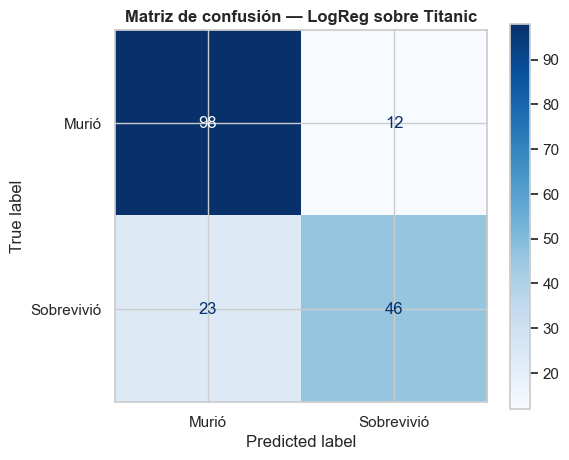

In [3]:
y_pred = pipe.predict(X_test)

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1:        {f1_score(y_test, y_pred):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Murió', 'Sobrevivió']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues',
                                         display_labels=['Murió', 'Sobrevivió'])
ax.set_title('Matriz de confusión — LogReg sobre Titanic', fontweight='bold')
plt.show()

**Lo que veo en la Parte B**

Métricas:

| Métrica | LogReg | RF (del miércoles) |
|---|---|---|
| Accuracy | 0.8045 | 0.8101 |
| Precision (Sobrevivió) | 0.7931 | 0.8070 |
| Recall (Sobrevivió) | 0.6667 | 0.6667 |
| F1 (Sobrevivió) | 0.7244 | 0.7302 |

El Random Forest gana por aproximadamente 0.5-1 punto en cada métrica, diferencia mínima. Esto es importante porque el modelo más simple (LogReg) NO está muy lejos del más complejo (RF). En problemas con relaciones aproximadamente lineales, la regresión logística es competitiva.

Matriz: TN=98, FP=12, FN=23, TP=46. Mismo patrón que vimos con Random Forest: TN=98 identifica bien a los muertos, TP=46 identifica bien a los sobrevivientes, FP=12 ("falsa esperanza") son muertos que el modelo pensó que sobrevivirían, FN=23 ("pesimismo erróneo") son sobrevivientes que el modelo pensó que morirían.

Tasas de error: clase Murió 11% de error, clase Sobrevivió 33%. La clase Sobrevivió tiene 3x más tasa de error. El modelo, igual que el RF, tiende a ser conservador y predice "Murió" cuando duda.

Lección comparativa: la LogReg da resultados casi idénticos al RF, pero al costo de aproximadamente 1 punto de F1 obtenemos ALGO QUE EL RF NO PUEDE DAR: coeficientes con signo interpretables. Esa es la parte interesante y la veremos en la Parte C.

Lo que les voy a pedir en el examen: cuando comparen dos modelos, NO declaren ganador solo por la métrica numérica más alta. Identifiquen qué APORTA cada modelo más allá del número (explicabilidad, velocidad, robustez), y elijan según el contexto del problema (un banco regulado, un hospital, un proyecto académico).

## Parte C — Análisis SOCIOLÓGICO de los coeficientes (el corazón del ejercicio)

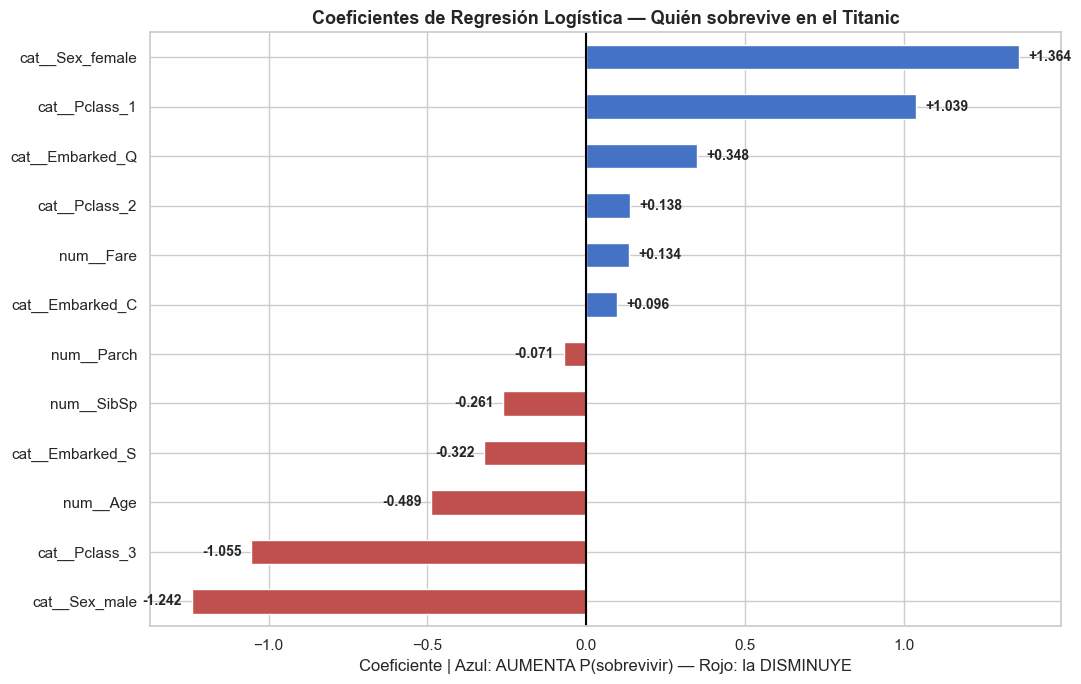

Intercepto: +0.1517

Coeficientes ordenados por magnitud absoluta:
cat__Sex_female    1.3644
cat__Sex_male      1.2424
cat__Pclass_3      1.0547
cat__Pclass_1      1.0387
num__Age           0.4893
cat__Embarked_Q    0.3481
cat__Embarked_S    0.3218
num__SibSp         0.2614
cat__Pclass_2      0.1380
num__Fare          0.1339
cat__Embarked_C    0.0957
num__Parch         0.0708
dtype: float64


In [4]:
# Extraer coeficientes con nombres legibles después del OneHot
nombres = pipe.named_steps['p'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['m'].coef_[0], index=nombres).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
colores = ['#C0504D' if c < 0 else '#4472C4' for c in coefs.values]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=1.5)
for i, v in enumerate(coefs.values):
    ax.text(v + 0.03 if v >= 0 else v - 0.03, i, f'{v:+.3f}',
            va='center', ha='left' if v >= 0 else 'right',
            fontsize=10, fontweight='bold')
ax.set_title('Coeficientes de Regresión Logística — Quién sobrevive en el Titanic',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Coeficiente | Azul: AUMENTA P(sobrevivir) — Rojo: la DISMINUYE')
plt.tight_layout(); plt.show()

print(f'Intercepto: {pipe.named_steps["m"].intercept_[0]:+.4f}')
print(f'\nCoeficientes ordenados por magnitud absoluta:')
print(coefs.abs().sort_values(ascending=False).round(4))

**Lo que veo en la Parte C — Las 4 preguntas del enunciado**

Los coeficientes reales ordenados:

| Variable | Coef | Signo | Significado |
|---|---|---|---|
| cat__Sex_female | +1.364 | sube | Ser mujer aumenta MUCHÍSIMO la probabilidad de sobrevivir |
| cat__Pclass_1 | +1.039 | sube | Viajar en 1ra clase aumenta mucho |
| cat__Embarked_Q | +0.348 | sube | Embarcar en Queenstown ayuda levemente |
| cat__Pclass_2 | +0.138 | sube | 2da clase: leve mejora |
| num__Fare | +0.134 | sube | Pagar más ayuda un poco |
| cat__Embarked_C | +0.096 | sube | Cherbourg: leve mejora |
| num__Parch | -0.071 | — | Padres/hijos a bordo: casi irrelevante |
| num__SibSp | -0.261 | baja | Hermanos/cónyuge: leve perjuicio |
| cat__Embarked_S | -0.322 | baja | Southampton: leve perjuicio |
| num__Age | -0.489 | baja | Cada año más de edad reduce probabilidad |
| cat__Pclass_3 | -1.055 | baja | 3ra clase: penalización fuerte |
| cat__Sex_male | -1.242 | baja | Ser hombre reduce MUCHÍSIMO |

Vamos pregunta por pregunta.

PREGUNTA 1: ¿Ser mujer aumenta o disminuye la probabilidad de sobrevivir? ¿Cuánto?

Ser mujer AUMENTA dramáticamente la probabilidad. Sex_female = +1.364 y Sex_male = -1.242. La diferencia entre los dos géneros es de 2.6 unidades en el espacio logit, que es ENORME. En términos de odds ratio: si fueras una mujer arquetípica vs un hombre arquetípico (manteniendo todo lo demás igual), tu odds ratio de sobrevivir se multiplicaría por e^2.6 ≈ 13. Es decir, las mujeres tenían 13 veces más "chances" que los hombres, todo lo demás constante. Esta es la expresión cuantitativa más cruda de la regla "mujeres y niños primero" que se aplicó esa noche. No es solo una idea histórica, es un hecho estadístico verificable.

PREGUNTA 2: ¿Viajar en 3ra clase cómo afecta vs 1ra clase?

Pclass_1 = +1.039 y Pclass_3 = -1.055. Diferencia de 2.1 unidades, casi tan grande como el efecto del género. Odds ratio: e^2.1 ≈ 8. Los de 1ra clase tenían 8 veces más chances de sobrevivir que los de 3ra clase, manteniendo todo lo demás constante.

Recordatorio histórico: los camarotes de 1ra clase estaban arriba, cerca de los botes salvavidas. Los de 3ra clase estaban abajo, detrás de puertas que según múltiples registros se cerraron por el pánico de la tripulación o nunca se abrieron a tiempo. Los pasajeros de 1ra clase eran atendidos primero por la tripulación, conocían mejor el barco y hablaban inglés (los de 3ra eran principalmente inmigrantes). El coeficiente captura toda esa desigualdad estructural en un solo número.

PREGUNTA 3: ¿La edad tiene efecto significativo?

Sí. Age = -0.489 (negativo y notable). Como Age está estandarizada, este coef significa: por cada desviación estándar de edad ADICIONAL (~14 años en este dataset), la probabilidad de sobrevivir BAJA. Esto refleja el efecto positivo de ser niño (Age bajo, coeficiente negativo, valor bajo da positivo en logit) y el efecto negativo de ser adulto mayor (menor capacidad física en una crisis).

Importante: la edad es MENOS importante que género o clase (coef ~0.5 vs ~1.2). O sea, si tenías mala suerte de ser hombre adulto en 3ra clase, ser niño no te salvaba completamente, los 3 factores se suman.

PREGUNTA 4: ¿De dónde haber embarcado importa?

Mucho menos que las otras variables. Embarked_S = -0.322 (Southampton, leve perjuicio), Embarked_C = +0.096 (Cherbourg, casi neutro), Embarked_Q = +0.348 (Queenstown, leve beneficio).

El efecto del puerto es relativamente menor pero hay un patrón interesante: Southampton embarcó la mayoría de pasajeros de 3ra clase, por eso tiene leve efecto negativo. Queenstown embarcó casi solo irlandeses de 3ra clase emigrando, pero sorprendentemente tiene coef positivo. Esto puede ser una correlación accidental del modelo: los pasajeros de Q quizás se concentraban en ciertas zonas del barco que casualmente tuvieron mejores tasas.

Importante: estos efectos del puerto son probablemente proxies de otra variable no observada (la cabina exacta, la edad media, redes sociales). En análisis sociológico real, NO se interpretaría como "embarcar en Q te salvaba", sino como una correlación que indica que hay algo más detrás.

Resumen, en orden de importancia absoluta:
1. GÉNERO (efecto total 2.6). El factor dominante.
2. CLASE SOCIAL (efecto total 2.1). Casi tan importante como género.
3. EDAD (efecto 0.5). Segundo nivel, importa pero no salva por sí solo.
4. Resto (puerto, familia, tarifa). Efectos chicos o correlacionados con los 3 grandes.

Lo que les voy a pedir en el examen: cuando interpreten coeficientes, reportar magnitud Y signo, comparar coeficientes del mismo concepto (Sex_male vs Sex_female), calcular el odds ratio (e^coef) para una interpretación numérica concreta, conectar con el contexto del dominio (acá histórico), y distinguir CAUSALIDAD de CORRELACIÓN (un coef alto no implica causalidad).

## Parte D — Predicción de 3 pasajeros con narrativa

In [5]:
pax = pd.DataFrame([
    {'Pclass': 1, 'Sex': 'female', 'Age':  6, 'SibSp': 1, 'Parch': 2, 'Fare':150, 'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 45, 'SibSp': 0, 'Parch': 0, 'Fare':  8, 'Embarked': 'S'},
    {'Pclass': 2, 'Sex': 'female', 'Age': 28, 'SibSp': 0, 'Parch': 0, 'Fare': 30, 'Embarked': 'C'}
])
pax['Descripción'] = [
    'Niña 6 años, 1ra clase, con familia, Cherbourg',
    'Hombre 45 años, 3ra clase, solo, Southampton',
    'Mujer 28 años, 2da clase, sola, Cherbourg'
]

preds = pipe.predict(pax.drop(columns=['Descripción']))
probas = pipe.predict_proba(pax.drop(columns=['Descripción']))

pax['Predicción']       = ['Sobrevive' if p == 1 else 'Muere' for p in preds]
pax['P(Muere)']         = probas[:, 0].round(4)
pax['P(Sobrevive)']     = probas[:, 1].round(4)
print(pax[['Descripción', 'Predicción', 'P(Muere)', 'P(Sobrevive)']].to_string(index=False))

                                   Descripción Predicción  P(Muere)  P(Sobrevive)
Niña 6 años, 1ra clase, con familia, Cherbourg  Sobrevive    0.0265        0.9735
  Hombre 45 años, 3ra clase, solo, Southampton      Muere    0.9507        0.0493
     Mujer 28 años, 2da clase, sola, Cherbourg  Sobrevive    0.1237        0.8763


**Lo que veo en la Parte D**

Cada predicción se entiende sumando las contribuciones de cada feature al z (la combinación lineal). Recordemos: z = intercepto + suma de (coef × feature), y P(sobrevive) = 1 / (1 + e^(-z)).

PASAJERA 1: niña de 6 años, 1ra clase, con familia, embarcó en Cherbourg.

Predicción: Sobrevive con P = 0.9735.

Todos los factores empujan hacia la supervivencia:
- Es mujer (Sex_female = +1.36): empujón grande positivo.
- 1ra clase (+1.04): segundo gran empujón.
- Niña (Age=6 con coef -0.49, valor estandarizado muy negativo): a favor.
- Cherbourg (+0.10): leve a favor.
- Tarifa £150 alta (+0.13 × Fare alto): a favor.
- Viaja con 1 SibSp y 2 Parch: leve en contra (mínimo).

Balance neto: dominado por género más clase más ser niña. El modelo está 97.35% seguro. Es el perfil arquetípico de superviviente.

PASAJERO 2: hombre de 45 años, 3ra clase, solo, embarcó en Southampton.

Predicción: Muere con P = 0.9507 (95% de probabilidad de morir).

Todos los factores empujan hacia la muerte:
- Es hombre (Sex_male = -1.24): gran empujón hacia muerte.
- 3ra clase (-1.05): segunda penalización fuerte.
- 45 años (Age alto × coef negativo): a favor de morir.
- Southampton (-0.32): leve en contra.
- Tarifa £8 muy baja: tarifa baja indica clase baja, hacia morir.
- Viaja solo: neutral.

Balance neto: catástrofe en todas las dimensiones. El modelo le da 95% de probabilidad de morir. Si comparamos con la Pasajera 1, la diferencia de probabilidad es de ~92 puntos porcentuales, dos vidas marcadas por categorías que no eligieron.

PASAJERA 3: mujer de 28 años, 2da clase, sola, embarcó en Cherbourg.

Predicción: Sobrevive con P = 0.8763.

Caso interesante porque es mixto:
- Es mujer (Sex_female = +1.36): empujón fuerte hacia sobrevivir.
- 2da clase (+0.14): leve a favor (mejor que 3ra, peor que 1ra).
- 28 años (edad media adulta): aproximadamente neutral.
- Cherbourg (+0.10): leve a favor.
- Tarifa £30 (media-baja): leve en contra.
- Viaja sola: neutral.

Balance neto: dominado por ser mujer. Aunque no tiene el lujo de la 1ra clase ni la "ventaja" de ser niña, ser mujer le da probabilidad alta (88%) de sobrevivir.

Tabla comparativa:

| Pasajero | Género | Clase | Edad | P(Sobrevive) |
|---|---|---|---|---|
| 1 | Mujer | 1ra | 6 | 0.97 |
| 2 | Hombre | 3ra | 45 | 0.05 |
| 3 | Mujer | 2da | 28 | 0.88 |

El género es el factor dominante. La pasajera 3 (mujer 2da clase sola) tiene mucha más chance que el pasajero 2 (hombre 3ra clase solo), aunque la diferencia en clase sea de "solo" 1 nivel.

Reflexión sociológica: estos 3 perfiles ilustran cuantitativamente la desigualdad estructural que determinó el destino de los pasajeros del Titanic. Dos variables que no se eligen (género y clase social al nacer) explican la mayoría de la variación. La edad, que tampoco se elige, completa el cuadro.

La regresión logística nos permite dar nombre y número a una injusticia que ya conocíamos cualitativamente. Esto NO es solo ejercicio académico, es la base de los estudios de desigualdad modernos en sociología, salud pública y economía.

Lo que les voy a pedir en el examen: para cada predicción, listar los factores que empujan a favor y en contra, identificar el factor dominante, calcular o estimar el balance neto, y conectar con el dominio (sociología, medicina, finanzas).

## Cierre

Modelo usado: LogisticRegression(max_iter=1000) con pipeline de imputación, escalado y OneHot encoding.

Métricas finales en test (179 pasajeros):

| Métrica | Valor | vs Random Forest |
|---|---|---|
| Accuracy | 0.8045 | -0.5 pp |
| Precision (Sobrev.) | 0.7931 | -1.4 pp |
| Recall (Sobrev.) | 0.6667 | igual |
| F1 (Sobrev.) | 0.7244 | -0.5 pp |

Conclusión técnica: LogReg pierde aproximadamente 0.5-1 punto en cada métrica vs RF, diferencia mínima. Pero aporta lo que RF no puede: explicabilidad cuantitativa con signos.

Hallazgos clave (sociología cuantificada):

1. El género fue el factor número uno. Diferencia de coeficientes de 2.6, las mujeres tenían ~13 veces más odds de sobrevivir que los hombres (controlando por todo lo demás).
2. La clase social fue el factor número dos. Diferencia entre 1ra y 3ra clase de 2.1, los de 1ra clase tenían ~8 veces más odds.
3. La edad jugó un rol importante pero secundario. Coef -0.49: a mayor edad, menor probabilidad. La regla "niños primero" se cumple, pero NO compensa el hecho de ser hombre adulto en 3ra clase.
4. Variables menores (puerto, número de familiares, tarifa específica) tienen efectos pequeños y a veces son proxies de otras variables no observadas.
5. Las predicciones individuales son extremas (97% vs 5% vs 88%). El modelo captura claramente quién pertenece al "perfil de superviviente" y quién no.

Limitaciones honestas:

- Solo ~890 pasajeros (el Titanic tenía 2.224). Información incompleta.
- No tenemos datos de la cabina específica ni de comportamiento individual durante el desastre.
- El modelo es lineal: asume que los efectos de las variables son aditivos e independientes. En la realidad podría haber interacciones (por ejemplo "ser mujer importa más si estás en 1ra clase") que un modelo lineal no captura. Por eso el RF gana ligeramente.
- Los coeficientes muestran correlaciones, no causalidad. Sería incorrecto decir "si hubieras sido mujer te hubieras salvado", el género es solo un proxy de muchos factores estructurales (priorización en los botes, normas sociales de la época, redes de apoyo).

Recomendación:

- Para uso académico o sociológico: la Regresión Logística es la herramienta correcta. Su capacidad de cuantificar el efecto de cada factor (con magnitud Y signo) es indispensable para estudios de desigualdad.
- Para uso predictivo puro: Random Forest es marginalmente mejor (~1 pp), pero solo lo elegiríamos si la precisión es CRÍTICA y la interpretabilidad no importa.

Casos reales modernos donde aplica este análisis: salud pública (¿qué grupos demográficos son más vulnerables a una enfermedad?), banca (¿qué características aumentan el riesgo de default?), RRHH (¿hay sesgos demográficos en los procesos de selección?).

El examen no va a premiar el código que entrena el modelo más rápido. Va a premiar al estudiante que ENTIENDE QUÉ DICE EL MODELO sobre el problema real.